# 📊 19 - Error Visualization: Error Bars & Confidence Intervals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 🎯 Learning Objectives

In this notebook, you'll learn:
- Creating error bars for line plots
- Error bars for bar charts
- Confidence intervals with `fill_between()`
- Asymmetric error bars
- Combining multiple uncertainty visualizations
- Best practices for scientific plotting

## 📊 1. Basic Error Bars (Vertical)

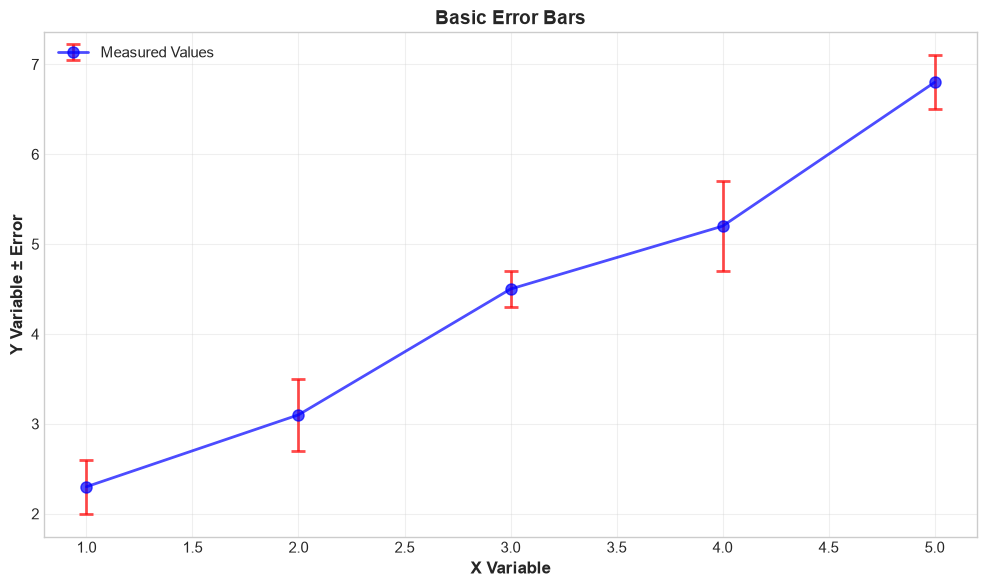

In [2]:
# Sample data with errors
x = np.array([1, 2, 3, 4, 5])
y = np.array([2.3, 3.1, 4.5, 5.2, 6.8])
yerr = np.array([0.3, 0.4, 0.2, 0.5, 0.3])

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(x, y, yerr=yerr, fmt='o-', linewidth=2, markersize=8,
            capsize=5, capthick=2, ecolor='red', 
            label='Measured Values', color='blue', alpha=0.7)

ax.set_xlabel('X Variable', fontsize=12, fontweight='bold')
ax.set_ylabel('Y Variable ± Error', fontsize=12, fontweight='bold')
ax.set_title('Basic Error Bars', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📉 2. Error Bars on Bar Charts

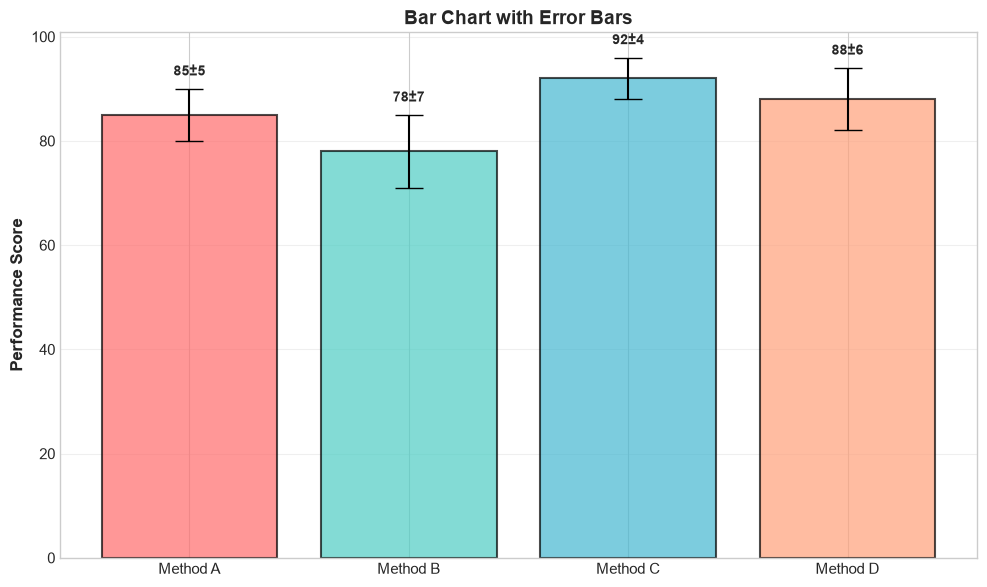

In [3]:
# Sample data for bar chart
categories = ['Method A', 'Method B', 'Method C', 'Method D']
values = np.array([85, 78, 92, 88])
errors = np.array([5, 7, 4, 6])

fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(categories))
bars = ax.bar(x_pos, values, yerr=errors, 
              color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'],
              alpha=0.7, capsize=10, edgecolor='black', linewidth=1.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(categories)
ax.set_ylabel('Performance Score', fontsize=12, fontweight='bold')
ax.set_title('Bar Chart with Error Bars', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val, err) in enumerate(zip(bars, values, errors)):
    ax.text(bar.get_x() + bar.get_width()/2, val + err + 2, 
            f'{val}±{err}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 🌈 3. Confidence Intervals with fill_between()

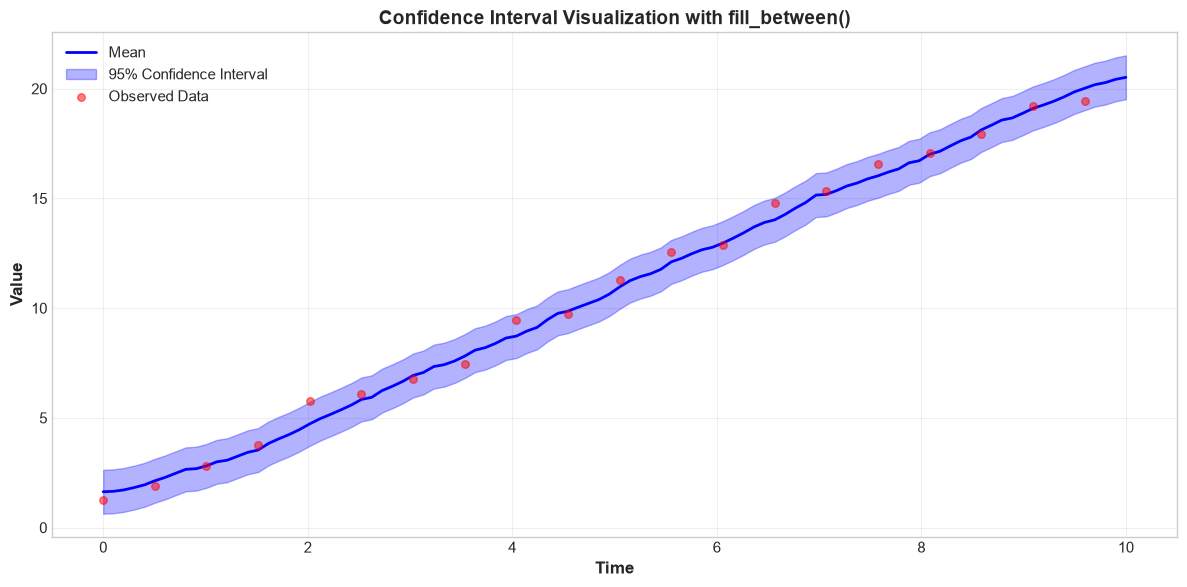

In [4]:
# Generate time series data with confidence intervals
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = 2 * x + 1 + np.random.randn(100) * 0.5

# Calculate moving average and confidence interval
from scipy.ndimage import uniform_filter1d
y_smooth = uniform_filter1d(y, size=10)
y_upper = y_smooth + 1.0
y_lower = y_smooth - 1.0

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the main line
ax.plot(x, y_smooth, color='blue', linewidth=2, label='Mean')

# Add confidence interval
ax.fill_between(x, y_lower, y_upper, alpha=0.3, color='blue', label='95% Confidence Interval')

# Add raw data points
ax.scatter(x[::5], y[::5], color='red', s=30, alpha=0.5, label='Observed Data', zorder=5)

ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Value', fontsize=12, fontweight='bold')
ax.set_title('Confidence Interval Visualization with fill_between()', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔄 4. Asymmetric Error Bars

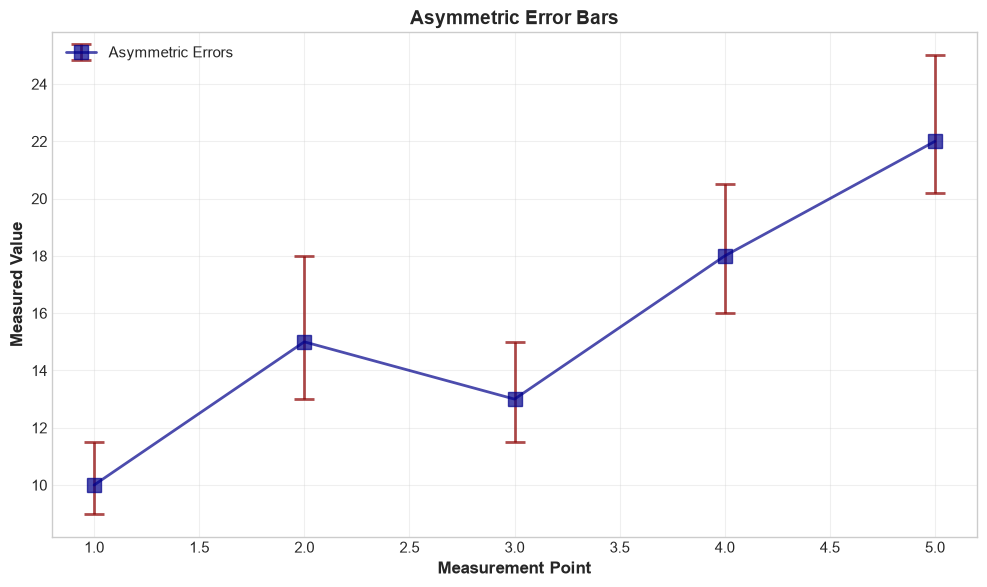

In [5]:
# Data with asymmetric errors (common in scientific measurements)
x = np.array([1, 2, 3, 4, 5])
y = np.array([10, 15, 13, 18, 22])
yerr_lower = np.array([1, 2, 1.5, 2, 1.8])
yerr_upper = np.array([1.5, 3, 2, 2.5, 3])

fig, ax = plt.subplots(figsize=(10, 6))

# Create asymmetric error bars
ax.errorbar(x, y, yerr=[yerr_lower, yerr_upper], 
            fmt='s-', linewidth=2, markersize=10,
            capsize=7, capthick=2, ecolor='darkred',
            color='darkblue', alpha=0.7, label='Asymmetric Errors')

ax.set_xlabel('Measurement Point', fontsize=12, fontweight='bold')
ax.set_ylabel('Measured Value', fontsize=12, fontweight='bold')
ax.set_title('Asymmetric Error Bars', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 5. Both X and Y Error Bars

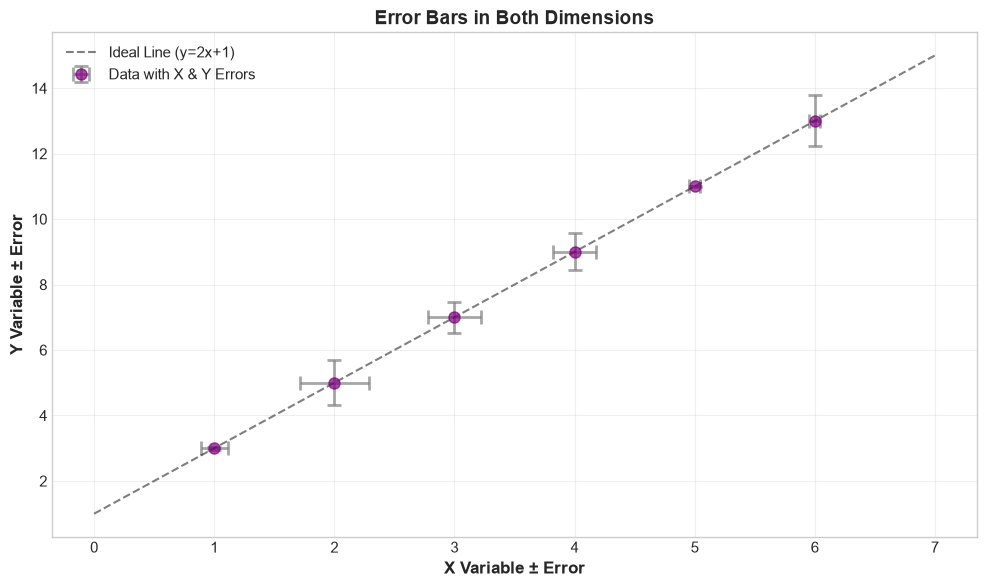

In [6]:
# Data with errors in both dimensions
np.random.seed(42)
x = np.array([1, 2, 3, 4, 5, 6])
y = 2 * x + 1
xerr = np.random.rand(len(x)) * 0.3
yerr = np.random.rand(len(x)) * 0.8

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(x, y, xerr=xerr, yerr=yerr, 
            fmt='o', markersize=8, linewidth=2,
            capsize=5, capthick=2, 
            ecolor='gray', color='purple', alpha=0.7,
            label='Data with X & Y Errors')

# Add ideal line
x_line = np.linspace(0, 7, 100)
y_line = 2 * x_line + 1
ax.plot(x_line, y_line, 'k--', linewidth=1.5, alpha=0.5, label='Ideal Line (y=2x+1)')

ax.set_xlabel('X Variable ± Error', fontsize=12, fontweight='bold')
ax.set_ylabel('Y Variable ± Error', fontsize=12, fontweight='bold')
ax.set_title('Error Bars in Both Dimensions', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔬 6. Real-World Example: Scientific Experiment

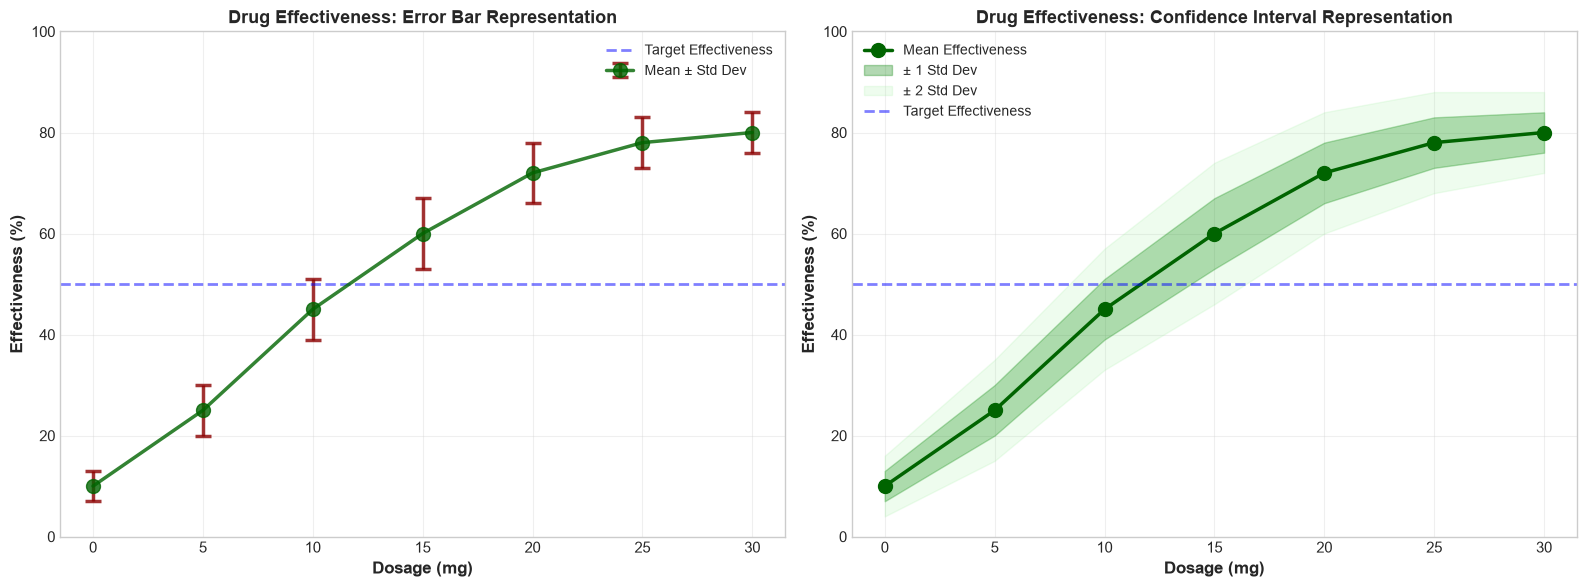


📊 Experimental Summary:
Optimal dosage appears to be around 20 mg
Target effectiveness (50%) reached at approximately 15 mg


In [7]:
# Simulate experimental data: drug effectiveness vs dosage
np.random.seed(42)
dosage = np.array([0, 5, 10, 15, 20, 25, 30])
effectiveness = np.array([10, 25, 45, 60, 72, 78, 80])
std_dev = np.array([3, 5, 6, 7, 6, 5, 4])

# Create multiple representations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Error bars with standard deviation
ax1.errorbar(dosage, effectiveness, yerr=std_dev, 
             fmt='o-', linewidth=2.5, markersize=10,
             capsize=6, capthick=2.5, ecolor='darkred',
             color='darkgreen', alpha=0.8, label='Mean ± Std Dev')

ax1.axhline(y=50, color='blue', linestyle='--', linewidth=2, alpha=0.5, label='Target Effectiveness')
ax1.set_xlabel('Dosage (mg)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Effectiveness (%)', fontsize=12, fontweight='bold')
ax1.set_title('Drug Effectiveness: Error Bar Representation', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# Right: Shaded confidence interval
ax2.plot(dosage, effectiveness, 'o-', linewidth=2.5, markersize=10, 
         color='darkgreen', label='Mean Effectiveness')
ax2.fill_between(dosage, effectiveness - std_dev, effectiveness + std_dev,
                 alpha=0.3, color='green', label='± 1 Std Dev')
ax2.fill_between(dosage, effectiveness - 2*std_dev, effectiveness + 2*std_dev,
                 alpha=0.15, color='lightgreen', label='± 2 Std Dev')

ax2.axhline(y=50, color='blue', linestyle='--', linewidth=2, alpha=0.5, label='Target Effectiveness')
ax2.set_xlabel('Dosage (mg)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Effectiveness (%)', fontsize=12, fontweight='bold')
ax2.set_title('Drug Effectiveness: Confidence Interval Representation', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\n📊 Experimental Summary:")
print(f"Optimal dosage appears to be around {dosage[effectiveness >= 70][0]} mg")
print(f"Target effectiveness (50%) reached at approximately {dosage[3]} mg")

## 🎯 Key Takeaways

- ✅ Use `errorbar()` for point measurements with uncertainty
- ✅ Error bars show standard deviation, standard error, or confidence intervals
- ✅ `fill_between()` is great for continuous confidence intervals
- ✅ Asymmetric errors use `yerr=[lower, upper]` format
- ✅ Both X and Y errors can be shown simultaneously
- ✅ Combine error bars with reference lines for context
- ✅ Always label what the error bars represent (std dev, CI, etc.)

## 💡 Try It Yourself

1. Create error bars for experimental measurements
2. Show confidence intervals for regression predictions
3. Compare multiple measurements with their uncertainties
4. Visualize time series with confidence bands
5. Use asymmetric errors for skewed distributions